# Final Project: Spotify API Function

## Jane Dalessio, _Data 200_

### _May 9th, 2025_

In [73]:
# In order to run this code you must install Spotipy, a python library for the Spotify Web API
# Copy this into your terminal: pip install spotipy --upgrade
# This is the website I used for some of the Spotipy specific code :https://spotipy.readthedocs.io/en/2.25.1/
import spotipy
import pandas as pd
import matplotlib.pyplot as plt
from spotipy.oauth2 import SpotifyClientCredentials

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=os.environ["SPOTIPY_CLIENT_ID"],
    client_secret=os.environ["SPOTIPY_CLIENT_SECRET"]
))

In [75]:
# Import my data frame from Project 1
old_spotify_data = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

#### Main Python Function: 

In [78]:
# Define a function that takes a song name and an artist as input
    
def track_popularity_and_duration1(track_name, artist_name):

    # Create a query and search the track using the name and artist
    query = 'track:'+ track_name + ' artist:'+ artist_name
    result = sp.search(q = query, type = 'track', limit = 1)
    
    # Create items from the results, if the song cannot be found it returns an empty data base
    
    items = result['tracks']['items']
    if not items:
        return pd.DataFrame()
    
    track_info = items[0]
    # Find the popularity for the song
    popularity = track_info['popularity']
    # Find the duration of the song
    duration_ms = track_info['duration_ms']

    # Change the duration from milliseconds to seconds and minutes
    duration_sec = round(duration_ms/1000, 2)
    duration_min = round(duration_sec/60, 2)

   # Create a data frame from the song name and artist, as well as the new popularity and duration columns
    df = pd.DataFrame([{'track_name': track_name, 'artist(s)_name': artist_name, 'track_popularity': popularity, 
                        'duration_sec': duration_sec, 'duration_min': duration_min}])

    return df

#### Description:
For this project, I used the Spotify Web API. After creating an account, I obtained a __client ID__ and __client secret__, which allowed me to access the API. To work with it more easily in Python, I used the __Spotipy__ library. My goal was to generate a dataset that could be merged with my original dataset from Project 1, which I named `old_spotify_data`. With that in mind, I wrote a function designed to take inputs from the original dataset and return new information. This function accepts an __artist's name__ and a __track name__, uses `sp.search()` to find the song on Spotify, and extracts both the track's popularity and its duration in milliseconds. I then store those values in a new one-row data frame. To demonstrate this function, I first run it on a single example song.

#### Example:

In [82]:
example = track_popularity_and_duration1('Locked Up', 'Ingrid Michaelson')
# Example with a song I really like :)
example

,track_name,artist(s)_name,track_popularity,duration_sec,duration_min
0,Locked Up,Ingrid Michaelson,23,236.65,3.94


In [84]:
# Define second function that will build off of the first one and be able to take a data frame as the input
def track_popularity_and_duration2(data_frame):
    # Empty results list
    results = []

    # Create a loop that will go through the data base finding the artist name and song name
    for i in range(len(data_frame)):
        track = data_frame.iloc[i]['track_name']
        artist = data_frame.iloc[i]['artist(s)_name']

        # Run through my first function
        tracks_and_artists = track_popularity_and_duration1(track, artist)
        # Append to the results list
        results.append(tracks_and_artists)

    # Concat the list of data bases, fix the index 
    final_results = pd.concat(results, ignore_index = True)

    
    return final_results

#### Description:
To apply this function across my full dataset, I created a second function that loops through each row of `old_spotify_data`, calling the first function on every song. It returns a list of small data frames, one per track, which I combine using `pd.concat()` with `ignore_index=True` to reset the index correctly. Together, these functions generate a new data frame containing two additional variables, __track popularity__ and __duration__, that I can now use in further analysis and visualizations.

In [87]:
new_spotify_data = track_popularity_and_duration2(old_spotify_data)
# Example with my old data base from project 1
new_spotify_data

,track_name,artist(s)_name,track_popularity,duration_sec,duration_min
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",86,183.55,3.06
1,LALA,Myke Towers,83,197.92,3.30
2,vampire,Olivia Rodrigo,87,219.72,3.66
3,Cruel Summer,Taylor Swift,90,178.43,2.97
4,WHERE SHE GOES,Bad Bunny,79,231.70,3.86
...,...,...,...,...,...
834,My Mind & Me,Selena Gomez,58,147.60,2.46
835,Bigger Than The Whole Sky,Taylor Swift,65,218.50,3.64
836,A Veces (feat. Feid),"Feid, Paulo Londra",57,191.19,3.19
837,En La De Ella,"Feid, Sech, Jhayco",64,230.65,3.84


#### New Data Frame:
This is my new data frame with the extracted variables, aligned with my original dataset and ready to be merged. As I mentioned earlier, I used `pd.concat()` along with `ignore_index=True` to clean up the index and ensure everything lined up correctly. Because I was feeding Tidy Data into the function, the output remained tidy as well. One exception is that the new data frame has 838 rows, while the original had 846. This indicates that a few songs weren’t found by the Spotify API and returned empty results, likely due to naming mismatches or missing entries. Still, since __each variable has its own column__, __each song is represented in its own row__, and __each cell contains a single value__, the structure meets the definition of Tidy Data.

In [90]:
merged_spotify_data = pd.merge(old_spotify_data, new_spotify_data, on = ['track_name', 'artist(s)_name'], how = 'inner')
# Merged the data together
merged_spotify_data

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,track_popularity,duration_sec,duration_min
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,80,89,83,31,0,8,4,86,183.55,3.06
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,71,61,74,7,0,10,4,83,197.92,3.30
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,51,32,53,17,0,31,6,87,219.72,3.66
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,55,58,72,11,0,11,15,90,178.43,2.97
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,65,23,80,14,63,11,6,79,231.70,3.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,60,24,39,57,0,8,3,58,147.60,2.46
843,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,42,7,24,83,1,12,6,65,218.50,3.64
844,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,80,81,67,4,0,8,6,57,191.19,3.19
845,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,82,67,77,8,0,12,5,64,230.65,3.84


#### First Visualization
For my first visualization, I created a histogram of __song popularity__. At first glance, this might seem redundant since all of the songs in my dataset were among the top streamed tracks of 2023 and are therefore already considered popular. However, it’s important to understand how the popularity variable works in the Spotify API. It’s a score from 0 to 100, with 100 being the most popular, based not only on total plays but also on how recently the track has been played. In other words, it reflects __ongoing popularity__, not just whether a song was a hit in 2023. This means the histogram helps distinguish between songs that remained popular over time and those that may have been __one-hit wonders__. There is an obvious left-skew to this graph with a funny blip of songs that are very unpopular.

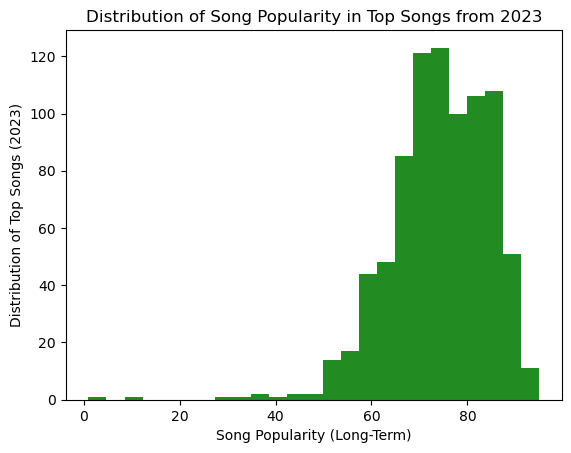

In [93]:
plt.hist(new_spotify_data['track_popularity'], bins = 25, color = 'forestgreen')
plt.title('Distribution of Song Popularity in Top Songs from 2023') 
plt.xlabel('Song Popularity (Long-Term)')
plt.ylabel('Distribution of Top Songs (2023)')
plt.show()

It was a little funny to me to see that certain songs on this list had a popularity rating of single digits, so I performed an aggregation to look at the “Top 10 Worst Songs” in this data base. 

In [96]:
# Thought I would have some fun and figure out what the least popular songs were in this table
bad_songs = new_spotify_data.sort_values('track_popularity', ascending = True).head(10)
bad_songs

,track_name,artist(s)_name,track_popularity,duration_sec,duration_min
60,Yellow,Chris Molitor,1,236.00,3.93
590,Contection,"GODZZ__-, Zakaria",12,123.90,2.06
308,"Apna Bana Le (From ""Bhediya"")","Arijit Singh, Sachin-Jigar",29,261.70,4.36
401,Happy Xmas (War Is Over),"John Lennon, The Harlem Community Choir, The P...",33,212.04,3.53
426,Deck The Hall - Remastered 1999,Nat King Cole,37,68.76,1.15
627,Wake Me Up - Radio Edit,Avicii,37,221.09,3.68
608,Something In The Way - Remastered 2021,Nirvana,40,232.20,3.87
319,Lovezinho,Treyce,43,129.64,2.16
403,The Christmas Song (Merry Christmas To You) - ...,Nat King Cole,45,192.16,3.20
781,"Come Back Home - From ""Purple Hearts""",Sofia Carson,47,176.86,2.95


#### Second Visualization
For my second visualization I made a scatter plot of __song popularity vs. song duration__. For the most part, this graph shows that the most popular songs from the top songs from 2023 are around 3-4 minutes in length. 

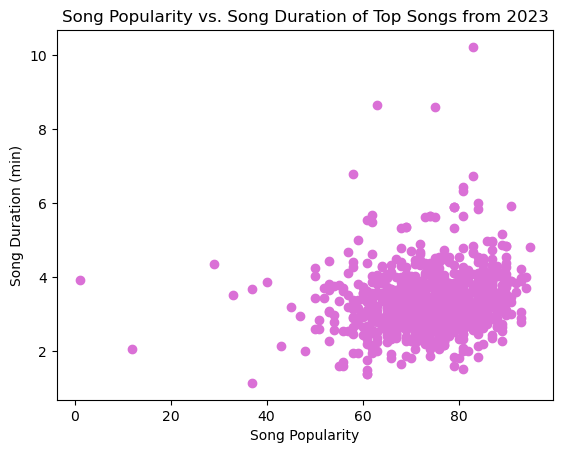

In [99]:
plt.scatter(new_spotify_data['track_popularity'], new_spotify_data['duration_min'], color = 'orchid')
plt.title('Song Popularity vs. Song Duration of Top Songs from 2023') 
plt.xlabel('Song Popularity')
plt.ylabel('Song Duration (min)')
plt.show()

#### Third Visualization
For my third visualization, I examined the __average song duration grouped by release year__. While this graph isn't the most precise, since my dataset doesn’t necessarily include songs from every year, it still produced some interesting insights. With a more balanced dataset that includes songs from multiple decades, this analysis could be much stronger. Going into it, I expected to see that songs have gotten shorter in recent years, assuming that "kids these days" have shorter attention spans and prefer songs under three minutes. Surprisingly, the average duration of modern songs over the last five years has held steady around the three-minute mark. The more unexpected patterns showed up in earlier years: song lengths peaked in the 1980s and dipped significantly in the 1990s and early 2000s. These trends would definitely be worth revisiting with a more comprehensive dataset. Still, this graph is useful for observing how the structure of popular music may have shifted over time.

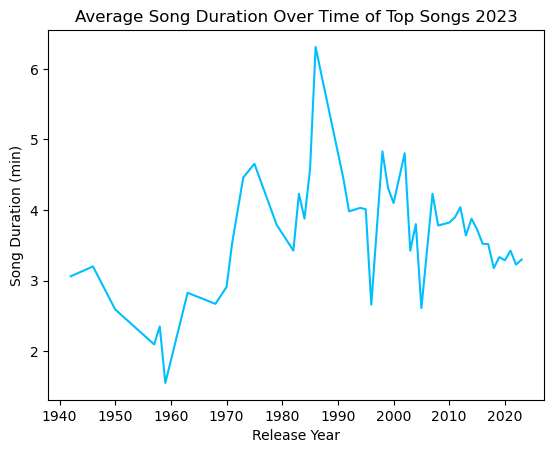

In [102]:
# Create an aggregation to get the average duration by year
avg_duration_by_year = merged_spotify_data.groupby('released_year')['duration_min'].mean()

# Plot it
plt.plot(avg_duration_by_year, color = 'deepskyblue')
plt.title('Average Song Duration Over Time of Top Songs 2023')
plt.xlabel('Release Year')
plt.ylabel('Song Duration (min)')
plt.show()

#### Fourth Visualization
For my final visualization, I created a scatter plot comparing __song popularity to the number of times a song appeared on the Spotify charts__. This graph, like my first, explores the relationship between short-term popularity and long-term impact. As expected, the visualization shows a clear trend: songs with higher popularity scores tend to appear more frequently on the charts. Interestingly, there’s also a noticeable cluster of songs that never appeared on the charts at all, despite being in the top streamed list of 2023. This highlights how many one-hit wonders or short-lived hits are represented in the dataset.

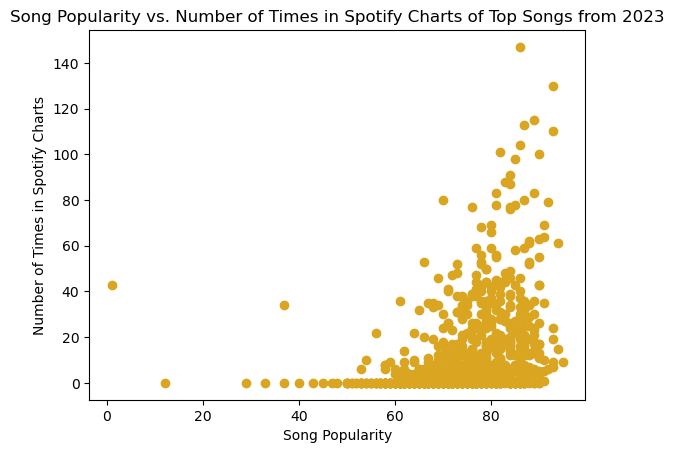

In [105]:
plt.scatter(merged_spotify_data['track_popularity'], merged_spotify_data['in_spotify_charts'], color = 'goldenrod')
plt.title('Song Popularity vs. Number of Times in Spotify Charts of Top Songs from 2023') 
plt.xlabel('Song Popularity')
plt.ylabel('Number of Times in Spotify Charts')
plt.show()

#### New Considerations with my Old Hypothesis:
Since this project builds on my first one, I was eager to revisit my original hypothesis that a __song’s speechiness level might be linked to the rise of rap and hip-hop genres__. Unfortunately, the Spotify API __did not include a genre variable__ for tracks, and there wasn’t a reliable substitute to help test this idea. If I had been able to access genre data, I could have compared it directly to speechiness levels to see whether songs labeled as rap or hip-hop showed higher speechiness, as I had initially observed. I also wanted to explore whether the popularity of these genres began to rise in the 1990s, when speechiness first spiked in my original dataset. With the right variables, these comparisons could have either supported or challenged my hypothesis by highlighting meaningful trends across time and genre.

That said, the variables I was able to add, track popularity and song duration, were valuable additions to my dataset. They allowed me to explore new angles, such as the difference between short-term and sustained popularity, and how song length varies across artists and years. These additions gave me a broader view of how certain songs perform and how the structure of popular music continues to evolve.


In [108]:
# Exported to a csv
csv = merged_spotify_data.to_csv('merged_spotify_data.csv', index = False)
csv